# 01 · Station Coverage Analysis

This notebook answers two questions before any modelling begins:

1. **How many counting stations are active in each month/year?**  
   The AWV network grew substantially over time; we need to understand which periods have dense, representative coverage.

2. **Does the 2023–2025 window give stable, near-complete coverage?**  
   We use the coverage statistics to justify our study-window choice and flag years that should be excluded or treated with caution.

**Data source:** `data/raw/cycling/YYYY/data-YYYY-MM.csv`  

## 0. Imports & Config

In [3]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

# ── paths (notebook lives in notebooks/, so parent = repo root) ───────────────
ROOT = Path().resolve().parent
RAW  = ROOT / "data" / "raw" / "cycling"
FIGS = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

# ── column schema ─────────────────────────────────────────────────────────────
CSV_COLS   = ["site ID", "richting", "type", "van", "tot", "aantal"]
USE_COLS   = ["site ID", "richting", "type", "van", "aantal"]
COL_DTYPES = {"site ID": "Int32", "richting": str, "type": str, "aantal": "float32"}
FNAME_RE   = re.compile(r"data-(\d{4})-(\d{2})\.csv$")

print(f"Repo root : {ROOT}")
print(f"Raw data  : {RAW}")
print(f"Figures   : {FIGS}")

Repo root : /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6
Raw data  : /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/raw/cycling
Figures   : /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/outputs/figures


## 1. Load All Cycling Data

Each monthly file is a headerless CSV with six columns. The loading pipeline:

- **`rglob('*.csv')`** discovers all files recursively under `data/raw/cycling/`.
- **`usecols`** drops `tot` (interval end) immediately — we only need the start timestamp.
- **FIETSERS filter** keeps only cyclist rows; other types (VOETGANGERS, AUTOS, …) are discarded.
- **IN + OUT aggregation** sums both directions per `(site, interval)` to avoid double-counting.
- **Daily aggregation** collapses 15-minute intervals into daily totals per site, which is the granularity used throughout the project.

In [4]:
def load_all_cycling_data(raw_dir: Path) -> pd.DataFrame:
    """Return a daily-aggregated DataFrame with columns:
    site ID | date | file_year | file_month | aantal
    """
    chunks = []
    for csv in sorted(raw_dir.rglob("*.csv")):
        m = FNAME_RE.search(csv.name)
        if not m:
            continue
        file_year, file_month = int(m.group(1)), int(m.group(2))

        df = pd.read_csv(
            csv, header=None, names=CSV_COLS,
            usecols=USE_COLS, dtype=COL_DTYPES,
        )
        df = df[df["type"] == "FIETSERS"]
        df["van"] = pd.to_datetime(df["van"], format="mixed")

        # sum IN + OUT → one row per (site, interval)
        df = (
            df.groupby(["site ID", "van"], as_index=False)["aantal"]
              .sum(min_count=1)
        )
        df["file_year"]  = file_year
        df["file_month"] = file_month
        chunks.append(df)

    raw = pd.concat(chunks, ignore_index=True)

    # aggregate to daily
    raw["date"] = raw["van"].dt.date
    daily = (
        raw.groupby(["site ID", "date", "file_year", "file_month"], as_index=False)
           ["aantal"].sum(min_count=1)
    )
    return daily


print("Loading all cycling CSV files")
daily = load_all_cycling_data(RAW)
print(f"\nLoaded {len(daily):,} daily rows across {daily['site ID'].nunique()} unique stations.")
print(f"Date range: {daily['date'].min()} → {daily['date'].max()}")
daily.head()

Loading all cycling CSV files

Loaded 222,176 daily rows across 150 unique stations.
Date range: 2019-08-01 → 2026-04-30


,site ID,date,file_year,file_month,aantal
0,1,2019-08-01,2019,8,495.0
1,1,2019-08-02,2019,8,364.0
2,1,2019-08-03,2019,8,273.0
3,1,2019-08-04,2019,8,424.0
4,1,2019-08-05,2019,8,455.0


In [5]:
print("Shape:", daily.shape)
print()
print(daily.dtypes)
print()
print("Missing values:")
print(daily.isnull().sum())

Shape: (222176, 5)

site ID         Int32
date           object
file_year       int64
file_month      int64
aantal        float32
dtype: object

Missing values:
site ID          0
date             0
file_year        0
file_month       0
aantal        5039
dtype: int64


## 2. Coverage Analysis

"Coverage" is defined as **the number of unique stations that report at least one cyclist count in a given (year, month)**.

We compute three views:
- **`cov_ym`** — `n_stations` and `pct` (share of all-time stations) per year–month pair  
- **`cov_y`** — `n_stations` per calendar year (union across all months)  
- **`pivot`** — year × month matrix of `pct`, used for the heatmap

In [6]:
def compute_coverage(daily: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """Return (cov_ym, total_stations).
    cov_ym columns: file_year | file_month | n_stations | pct
    """
    total = daily["site ID"].nunique()
    cov = (
        daily.groupby(["file_year", "file_month"])["site ID"]
             .nunique()
             .reset_index(name="n_stations")
    )
    cov["pct"] = (cov["n_stations"] / total * 100).round(1)
    return cov, total


def compute_annual_coverage(daily: pd.DataFrame) -> pd.DataFrame:
    """Return n_stations per year."""
    return (
        daily.groupby("file_year")["site ID"]
             .nunique()
             .reset_index(name="n_stations")
    )


def compute_heatmap_data(cov_ym: pd.DataFrame) -> pd.DataFrame:
    """Return year × month pivot of pct, sorted newest-year first."""
    pivot = cov_ym.pivot(index="file_year", columns="file_month", values="pct")
    return pivot.sort_index(ascending=False)


cov_ym, total_stations = compute_coverage(daily)
cov_y  = compute_annual_coverage(daily)
pivot  = compute_heatmap_data(cov_ym)

print(f"Total unique stations (all time): {total_stations}")
print(f"\ncov_ym shape: {cov_ym.shape}")
display(cov_ym.head(8))
print(f"\ncov_y:")
display(cov_y)

Total unique stations (all time): 150

cov_ym shape: (81, 4)


,file_year,file_month,n_stations,pct
0,2019,8,24,16.0
1,2019,9,24,16.0
2,2019,10,24,16.0
3,2019,11,24,16.0
4,2019,12,24,16.0
5,2020,1,24,16.0
6,2020,2,24,16.0
7,2020,3,24,16.0



cov_y:


,file_year,n_stations
0,2019,24
1,2020,25
2,2021,27
3,2022,130
4,2023,141
5,2024,141
6,2025,147
7,2026,145


## 3. Visualisations

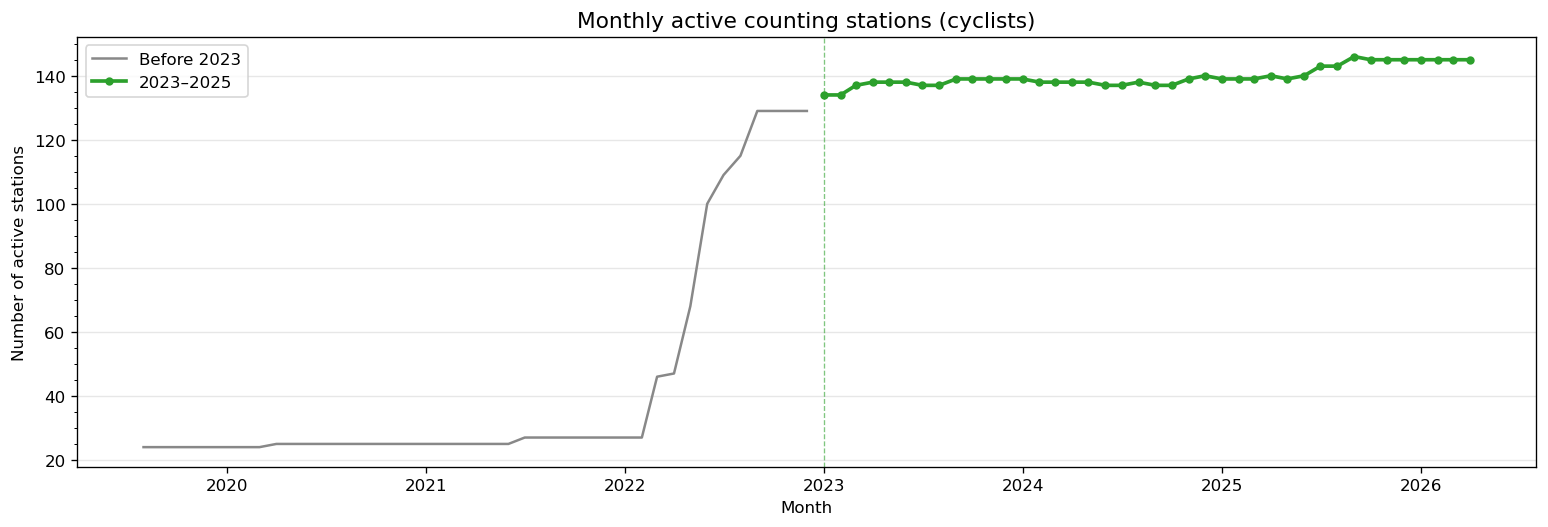

Saved 01_monthly_station_coverage.png


In [11]:
# Fig 01 — Monthly station count line plot (2023+ highlighted in green)
cov_ym_s = cov_ym.sort_values(["file_year", "file_month"]).copy()
cov_ym_s["ym"] = pd.to_datetime(
    cov_ym_s["file_year"].astype(str) + "-" +
    cov_ym_s["file_month"].astype(str).str.zfill(2)
)

mask_old = cov_ym_s["file_year"] < 2023
mask_new = cov_ym_s["file_year"] >= 2023

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(cov_ym_s.loc[mask_old, "ym"], cov_ym_s.loc[mask_old, "n_stations"],
        color="#888", lw=1.5, label="Before 2023")
ax.plot(cov_ym_s.loc[mask_new, "ym"], cov_ym_s.loc[mask_new, "n_stations"],
        color="#2ca02c", lw=2.2, marker="o", ms=4, label="2023–2025")
ax.axvline(pd.Timestamp("2023-01-01"), color="#2ca02c", lw=0.8, ls="--", alpha=0.6)
ax.set_title("Monthly active counting stations (cyclists)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Number of active stations")
ax.legend()
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "01_monthly_station_coverage.png", dpi=150)
plt.show()
print("Saved 01_monthly_station_coverage.png")

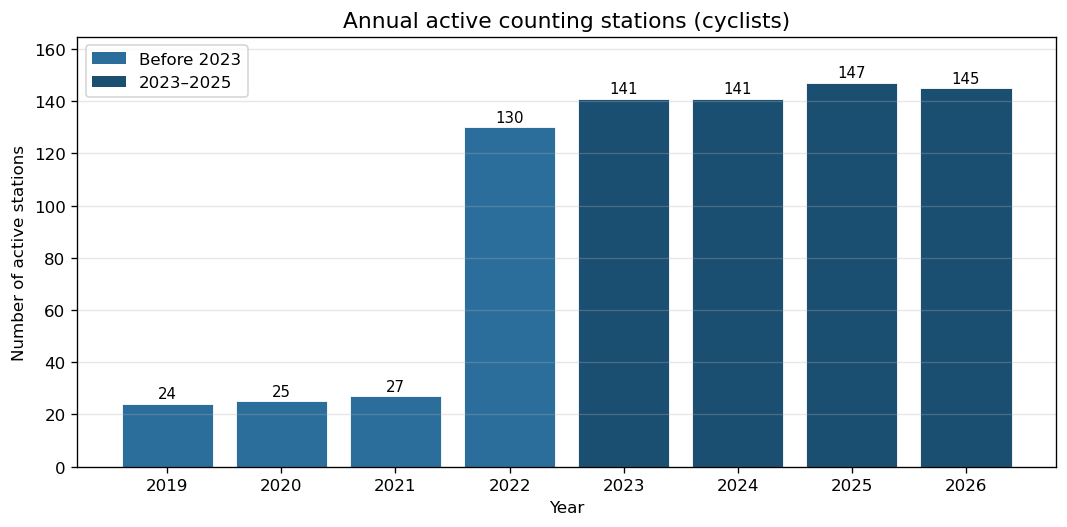

Saved 01_annual_station_coverage.png


In [12]:
# Fig 02 — Annual station count bar chart (2023+ in darker colour)
colors = ["#2c6e9b" if y < 2023 else "#1a4f72" for y in cov_y["file_year"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(cov_y["file_year"].astype(str), cov_y["n_stations"],
              color=colors, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, cov_y["n_stations"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(int(val)), ha="center", va="bottom", fontsize=9)

legend_els = [Patch(facecolor="#2c6e9b", label="Before 2023"),
              Patch(facecolor="#1a4f72", label="2023–2025")]
ax.legend(handles=legend_els)
ax.set_title("Annual active counting stations (cyclists)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Number of active stations")
ax.set_ylim(0, cov_y["n_stations"].max() * 1.12)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "01_annual_station_coverage.png", dpi=150)
plt.show()
print("Saved 01_annual_station_coverage.png")

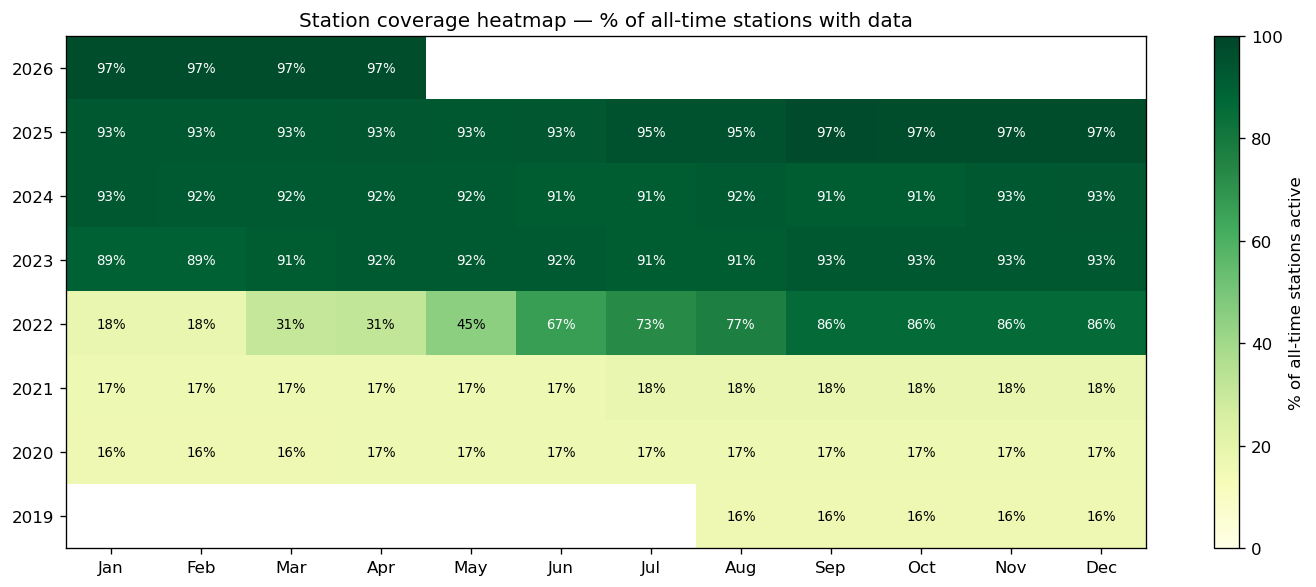

Saved 01_coverage_heatmap.png


In [9]:
# Fig 03 — Year × Month coverage heatmap
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGn", vmin=0, vmax=100)

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index.astype(str))

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                    fontsize=8, color="black" if val < 65 else "white")

plt.colorbar(im, ax=ax, label="% of all-time stations active")
ax.set_title("Station coverage heatmap — % of all-time stations with data", fontsize=12)
fig.tight_layout()
fig.savefig(FIGS / "01_coverage_heatmap.png", dpi=150)
plt.show()
print("Saved 01_coverage_heatmap.png")

## 4. Summary Statistics

In [13]:
def print_summary_stats(
    daily: pd.DataFrame,
    cov_ym: pd.DataFrame,
    cov_y: pd.DataFrame,
    total_stations: int,
) -> None:
    sep = "=" * 60
    print(sep)
    print(f"Total unique stations (all time): {total_stations}")
    print(sep)

    print("\nPer-year summary:")
    for _, row in cov_y.iterrows():
        yr    = int(row["file_year"])
        n_mon = cov_ym[cov_ym["file_year"] == yr].shape[0]
        pct   = cov_ym[cov_ym["file_year"] == yr]["pct"].mean()
        print(f"  {yr}: {int(row['n_stations']):>3} stations, "
              f"{n_mon:>2} months with data, "
              f"avg monthly coverage {pct:.1f}%")

    before = cov_ym[cov_ym["file_year"] < 2023]["n_stations"].mean()
    during = cov_ym[cov_ym["file_year"] >= 2023]["n_stations"].mean()
    print(f"\nAverage monthly active stations:")
    print(f"  Before 2023          : {before:.1f}")
    print(f"  2023 onward          : {during:.1f}")
    print(f"  Change               : {during - before:+.1f} "
          f"({(during / before - 1) * 100:+.1f}%)")
    print("  Note: 2019 data starts from August only.")

    min_cov_2023 = cov_ym[cov_ym["file_year"].isin([2023, 2024, 2025])]["pct"].min()
    print(f"\nMinimum monthly coverage in 2023–2025: {min_cov_2023:.1f}%")


print_summary_stats(daily, cov_ym, cov_y, total_stations)

Total unique stations (all time): 150

Per-year summary:
  2019:  24 stations,  5 months with data, avg monthly coverage 16.0%
  2020:  25 stations, 12 months with data, avg monthly coverage 16.5%
  2021:  27 stations, 12 months with data, avg monthly coverage 17.3%
  2022: 130 stations, 12 months with data, avg monthly coverage 58.6%
  2023: 141 stations, 12 months with data, avg monthly coverage 91.6%
  2024: 141 stations, 12 months with data, avg monthly coverage 92.0%
  2025: 147 stations, 12 months with data, avg monthly coverage 94.6%
  2026: 145 stations,  4 months with data, avg monthly coverage 96.7%

Average monthly active stations:
  Before 2023          : 43.5
  2023 onward          : 139.7
  Change               : +96.2 (+221.1%)
  Note: 2019 data starts from August only.

Minimum monthly coverage in 2023–2025: 89.3%
